# Member Feature Profile — `member_features.csv` (100k members)

**Project context:** member-level utilization-risk classification (Low / Medium / High) — see `Team1_RFC.docx`. This notebook profiles the modeling-ready feature table built by `src/build_features.py` (Task 5) and sanity-checks that risk-relevant structure exists in the features. **No model is trained here and no target is constructed** — per the project decision, modeling is out of scope for this milestone; the proxy in section 4 exists only to preview feature separability.

**Feature table.** One row per `person_id` (100,000 rows × 24 columns), documented in the *Modeling contract* section of `src/build_features.py` and in `REPORT.md`. Groups: demographics (`age`, `age_band`, `gender`, `race`, `ethnicity`, `state`), utilization (`inpatient_visits`, `outpatient_visits`, `er_visits`, `total_visits`, `distinct_care_sites`, `observation_months`), chronic-condition flags (`diabetes`, `chf`, `copd`, `stroke`, `cancer`, `renal_disease`), pharmacy (`drug_exposures`, `distinct_drugs`, `drug_eras`), and interaction breadth (`distinct_conditions`, `distinct_procedures`).

**Known caveats carried over from the EDA** (details in notebook 01 and the builder docstring): ~85% of visit rows are untyped, so the typed visit counts cover only ~15% of activity (no ER rows at all → `er_visits` is zero-variance); chronic flags are ICD-9 ANY-match flags inflated by claim-line duplication; `ethnicity` is byte-identical to `race`; `state` mixes USPS codes with a raw "54" code; there are no spending columns, so utilization *intensity* stands in for the RFC's spending features.


## 0. Setup — load the feature table

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

%matplotlib inline
sns.set_theme(style="whitegrid")

for candidate in (Path.cwd() / "src", Path.cwd().parent / "src"):
    if (candidate / "load_synpuf.py").exists():
        sys.path.insert(0, str(candidate))
        break

import load_synpuf

# Anchor everything to the loader's location so the notebook works
# regardless of where Jupyter was launched from.
PROJECT_ROOT = Path(load_synpuf.__file__).resolve().parent.parent

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

FEATURES_CSV = PROJECT_ROOT / "data" / "processed" / "member_features.csv"
df = pd.read_csv(FEATURES_CSV)

CHRONIC = ["diabetes", "chf", "copd", "stroke", "cancer", "renal_disease"]
COUNT_COLS = ["inpatient_visits", "outpatient_visits", "er_visits", "total_visits",
              "distinct_care_sites", "observation_months",
              "drug_exposures", "distinct_drugs", "drug_eras",
              "distinct_conditions", "distinct_procedures"]
NOMINAL_COLS = ["age_band", "gender", "race", "ethnicity", "state"]

print(f"{FEATURES_CSV}")
print(f"shape: {df.shape[0]:,} rows x {df.shape[1]} cols")
df.head()


/Users/sourangshupal/Downloads/final-project-usd/data/processed/member_features.csv
shape: 100,000 rows x 24 cols


,person_id,age,age_band,gender,race,ethnicity,state,inpatient_visits,outpatient_visits,er_visits,total_visits,distinct_care_sites,observation_months,diabetes,chf,copd,stroke,cancer,renal_disease,drug_exposures,distinct_drugs,drug_eras,distinct_conditions,distinct_procedures
0,34,89,85+,Female,1,1,NY,0,9,0,33,26,30,1,0,0,0,0,0,76,73,89,55,42
1,41,76,75-84,Male,1,1,TX,0,16,0,48,36,31,1,1,1,0,1,1,132,120,133,77,58
2,83,45,<65,Female,1,1,GA,3,18,0,145,105,35,1,1,1,1,0,1,160,146,164,230,155
3,103,89,85+,Male,1,1,MS,0,7,0,28,17,26,1,1,0,0,1,1,31,30,33,54,49
4,178,80,75-84,Male,1,1,MA,2,3,0,121,70,31,1,1,1,1,1,1,201,178,201,216,137


## 1. Integrity summary

Verify the artifact-level guarantees the modeling phase will rely on: one row per member, a unique row key, and full population of every column (counts/flags default to 0 via the builder's zero-fill).

In [2]:
# --- data-type contract from the Modeling contract ---
dtypes = df.dtypes.astype(str).rename("dtype")
non_numeric = dtypes[dtypes != "int64"].rename("non-int columns")
print("\nColumn dtype summary:")
print(dtypes.value_counts())
print("\nNon-integer columns (expected: the nominal/label columns):")
print(non_numeric)

# person_id is the row key, not a feature
print(f"\nperson_id: min={df['person_id'].min():,} max={df['person_id'].max():,} "
      f"(excluded from features per Modeling contract)")

# --- structural integrity of the artifact itself ---
integrity = pd.DataFrame({
    "check": [
        "rows == distinct person_id",
        "person_id is unique (row key)",
        "total null cells",
        "duplicate full rows",
    ],
    "result": [
        len(df) == df["person_id"].nunique(),
        not df["person_id"].duplicated().any(),
        int(df.isna().sum().sum()),
        int(df.duplicated().sum()),
    ],
})
integrity



Column dtype summary:
dtype
int64    21
str       3
Name: count, dtype: int64

Non-integer columns (expected: the nominal/label columns):
age_band    str
gender      str
state       str
Name: non-int columns, dtype: str

person_id: min=34 max=2,326,855 (excluded from features per Modeling contract)


,check,result
0,rows == distinct person_id,True
1,person_id is unique (row key),True
2,total null cells,0
3,duplicate full rows,0


**Takeaway.** The artifact is structurally clean: 100,000 rows for 100,000 distinct members, zero null cells, no duplicate rows. Of the 24 columns, 21 are `int64` — the 17 count/flag columns plus `person_id`, `age`, and the integer-coded `race`/`ethnicity` — and only `age_band`, `gender`, `state` are strings. Exactly the layout the Modeling contract specifies, so no imputation or type repair is needed — but encode `race`/`ethnicity` as categorical one-hots, never as numeric/ordinal features.


## 2. Univariate distributions

Who is in the table, and how are the count features and chronic flags distributed? All count features are expected to be right-skewed with a heavy high-utilization tail (and a zero-inflated minority), mirroring the EDA.

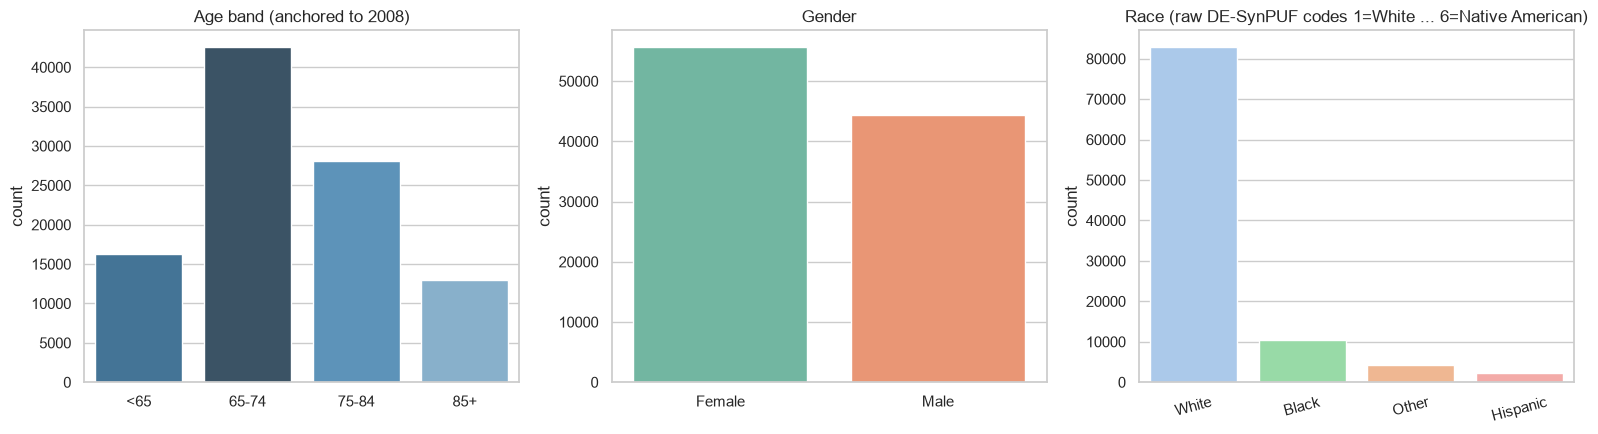

Age: mean 71.7, range 25-99
Race code 4 (Asian) count: 0  |  code 6 (Native American): 0  (neither appears in this export)


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

sns.countplot(data=df, x="age_band",
              order=["<65", "65-74", "75-84", "85+"],
              ax=axes[0], hue="age_band", palette="Blues_d", legend=False)
axes[0].set_title("Age band (anchored to 2008)")
axes[0].set_xlabel("")

sns.countplot(data=df, x="gender", ax=axes[1], hue="gender",
              palette="Set2", legend=False)
axes[1].set_title("Gender")
axes[1].set_xlabel("")

RACE_LABELS = {1: "White", 2: "Black", 3: "Other", 4: "Asian",
               5: "Hispanic", 6: "Native American"}
race_plot = df["race"].map(RACE_LABELS).fillna(df["race"].astype(str))
order = race_plot.value_counts().index
sns.countplot(x=race_plot, order=order, ax=axes[2], hue=race_plot,
              palette="pastel", legend=False)
axes[2].set_title("Race (raw DE-SynPUF codes 1=White ... 6=Native American)")
axes[2].set_xlabel("")
axes[2].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

print(f"Age: mean {df['age'].mean():.1f}, range {df['age'].min()}-{df['age'].max()}")
print(f"Race code 4 (Asian) count: {(df['race'] == 4).sum()}  |  code 6 (Native American): "
      f"{(df['race'] == 6).sum()}  (neither appears in this export)")


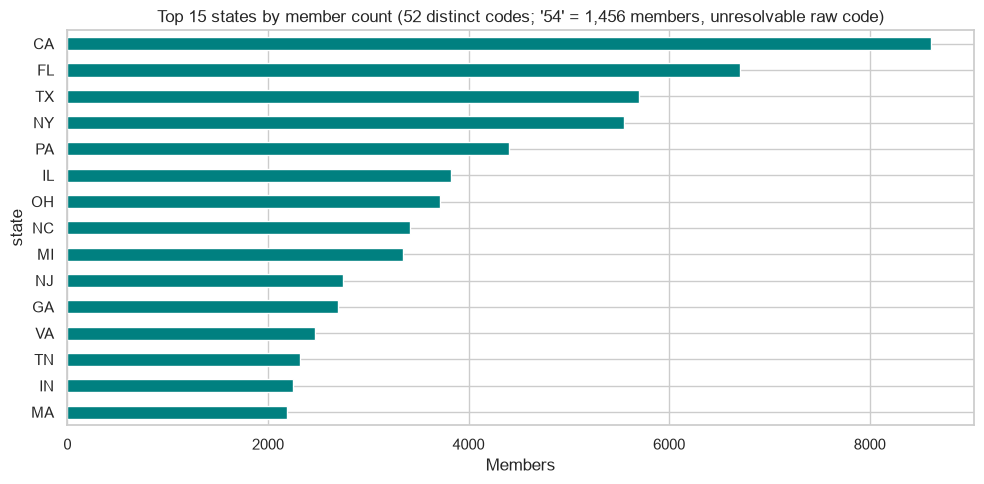

Distinct state codes: 52; '54' members: 1,456; state 'Missing': 0


state
CA    8609
FL    6711
TX    5699
NY    5547
PA    4404
IL    3829
OH    3716
NC    3415
Name: count, dtype: int64

In [4]:
top_states = df["state"].value_counts()
n_states = df["state"].nunique()

fig, ax = plt.subplots(figsize=(10, 5))
top_states.head(15).sort_values().plot.barh(ax=ax, color="teal")
ax.set_title(f"Top 15 states by member count "
             f"({n_states} distinct codes; '54' = {top_states.get('54', 0):,} members, "
             f"unresolvable raw code)")
ax.set_xlabel("Members")
plt.tight_layout()
plt.show()

print(f"Distinct state codes: {n_states}; '54' members: {(df['state'] == '54').sum():,}; "
      f"state 'Missing': {(df['state'] == 'Missing').sum():,}")
top_states.head(8)


In [5]:
zero_share = (df[COUNT_COLS] == 0).mean().sort_values()
print("Share of members at 0 (count features):")
print((zero_share * 100).round(1).to_string())


Share of members at 0 (count features):
observation_months      10.7
drug_exposures          11.3
distinct_drugs          11.3
drug_eras               11.8
total_visits            14.8
distinct_care_sites     14.8
distinct_procedures     15.0
distinct_conditions     15.4
outpatient_visits       27.0
inpatient_visits        67.7
er_visits              100.0


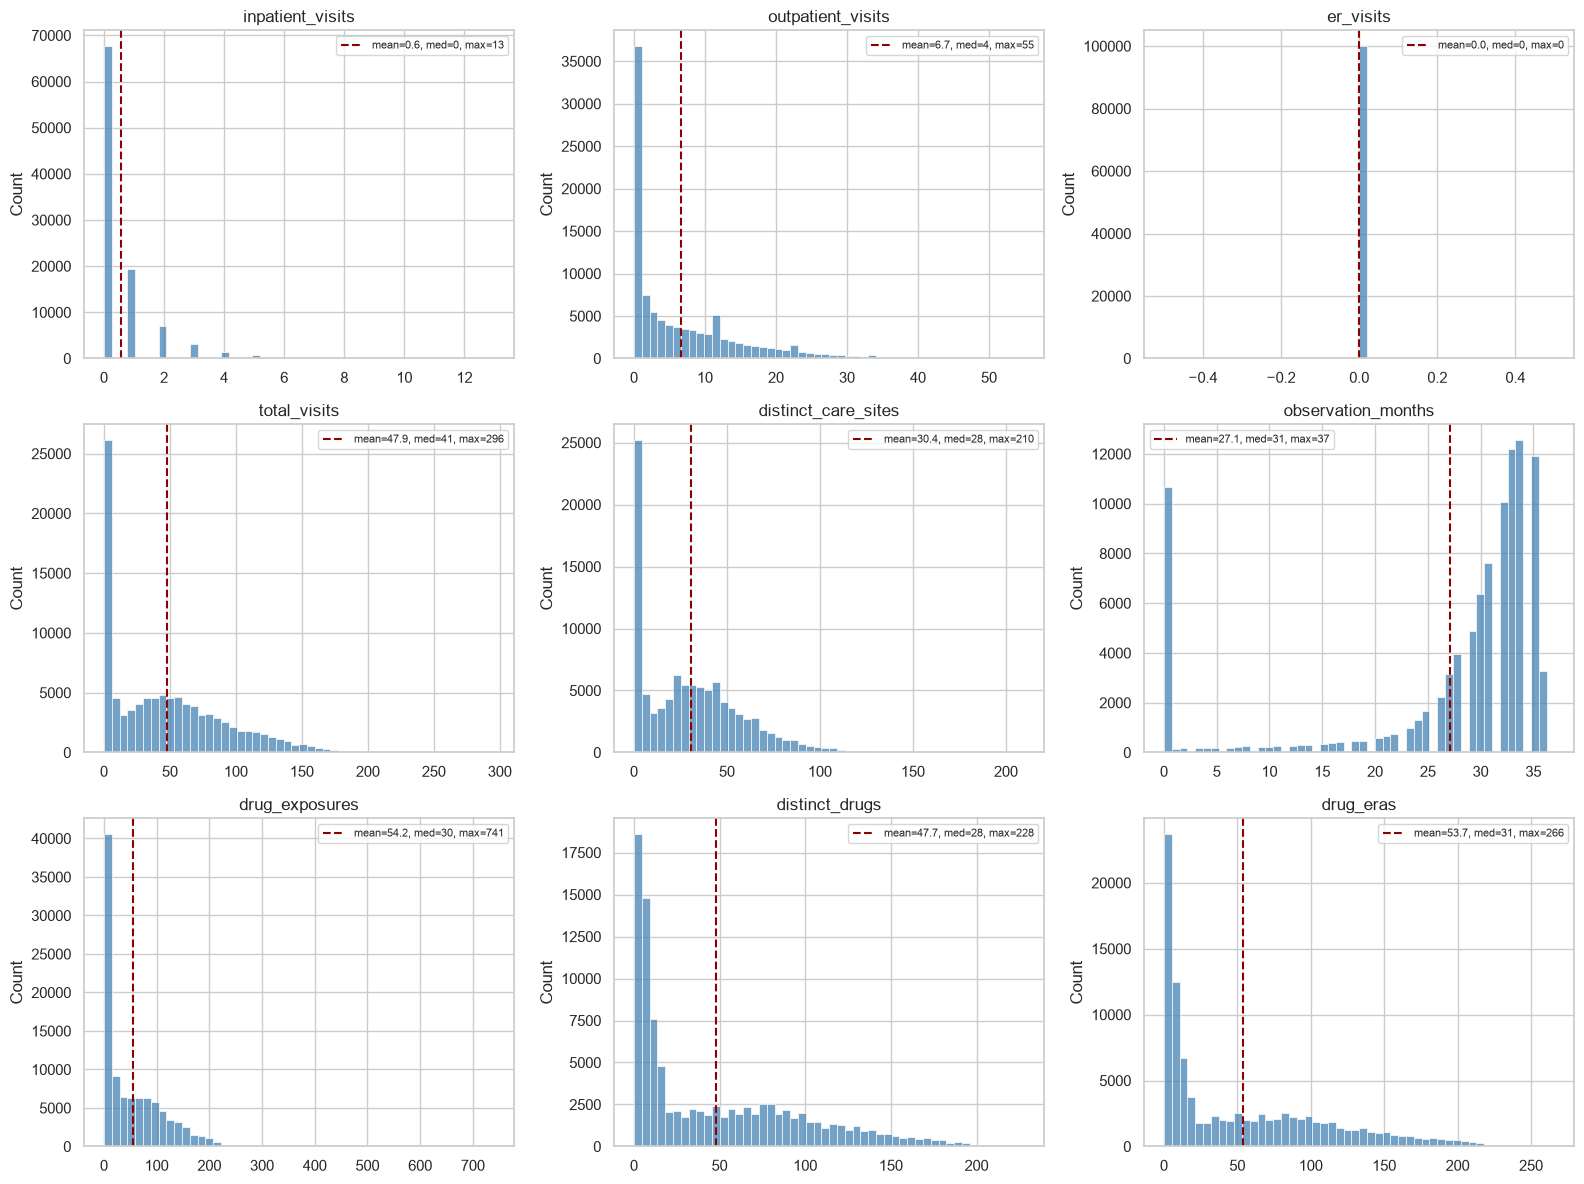

In [6]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
for ax, col in zip(axes.ravel(), COUNT_COLS):
    sns.histplot(df[col], bins=50, ax=ax, color="steelblue")
    ax.set_title(col)
    ax.set_xlabel("")
    ax.axvline(df[col].mean(), color="darkred", ls="--",
               label=f"mean={df[col].mean():.1f}, med={df[col].median():.0f}, max={df[col].max():.0f}")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


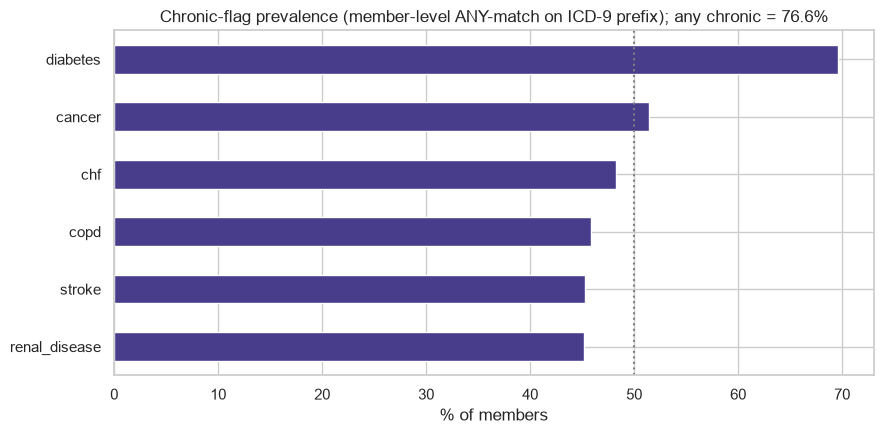

Chronic flags per member:
0    23394
1     8180
2     8786
3    11315
4    13833
5    16515
6    17977

mean flags/member = 3.05


In [7]:
prev = df[CHRONIC].mean().sort_values(ascending=False) * 100
any_chronic = df[CHRONIC].any(axis=1).mean() * 100

fig, ax = plt.subplots(figsize=(9, 4.5))
prev.sort_values().plot.barh(ax=ax, color="darkslateblue")
ax.set_title(f"Chronic-flag prevalence (member-level ANY-match on ICD-9 prefix); "
             f"any chronic = {any_chronic:.1f}%")
ax.set_xlabel("% of members")
ax.axvline(50, color="grey", ls=":")
plt.tight_layout()
plt.show()

# Flag co-occurrence: how many distinct chronic flags per member
n_flags = df[CHRONIC].sum(axis=1)
print("Chronic flags per member:")
print(n_flags.value_counts().sort_index().rename("members").to_string())
print(f"\nmean flags/member = {n_flags.mean():.2f}")


**Takeaways.**
- **Demographics** match the 1k EDA and the Medicare frame: mean age 71.7 (16% under 65 — disabled-eligible members), 55.6% female, 82.8% White; race codes 4/6 never occur, so `race` is effectively a 4-level variable.
- **Count features are all right-skewed** (mean ≈ 1.1–2.0× the median everywhere) with a sizable zero-inflated minority: 14.8% of members have *zero* visit rows and ~11–15% have no drug/procedure/condition activity at all. This bimodality is real signal for the Low-risk tier, not dirty data.
- **`er_visits` is all zeros** (no 9203 rows in this export) — zero-variance, to be dropped before fitting per the Modeling contract.
- **Chronic flags are common** (diabetes 69.6%, cancer 51.4%, CHF 48.2%; 76.6% of members carry ≥1 flag) — so as in the EDA, flag *combinations and counts* rather than presence will separate risk tiers. The prevalences are inflated by claim-line duplication and are utilization-flavored signals, not clinical truth.

## 3. Bivariate structure — correlations and utilization cross-tabs

Check (a) how the numeric features co-move, (b) whether chronic-flag prevalence rises with utilization, and (c) how utilization varies across age bands. Watch for multicollinearity clusters that the modeling phase may want to thin out.

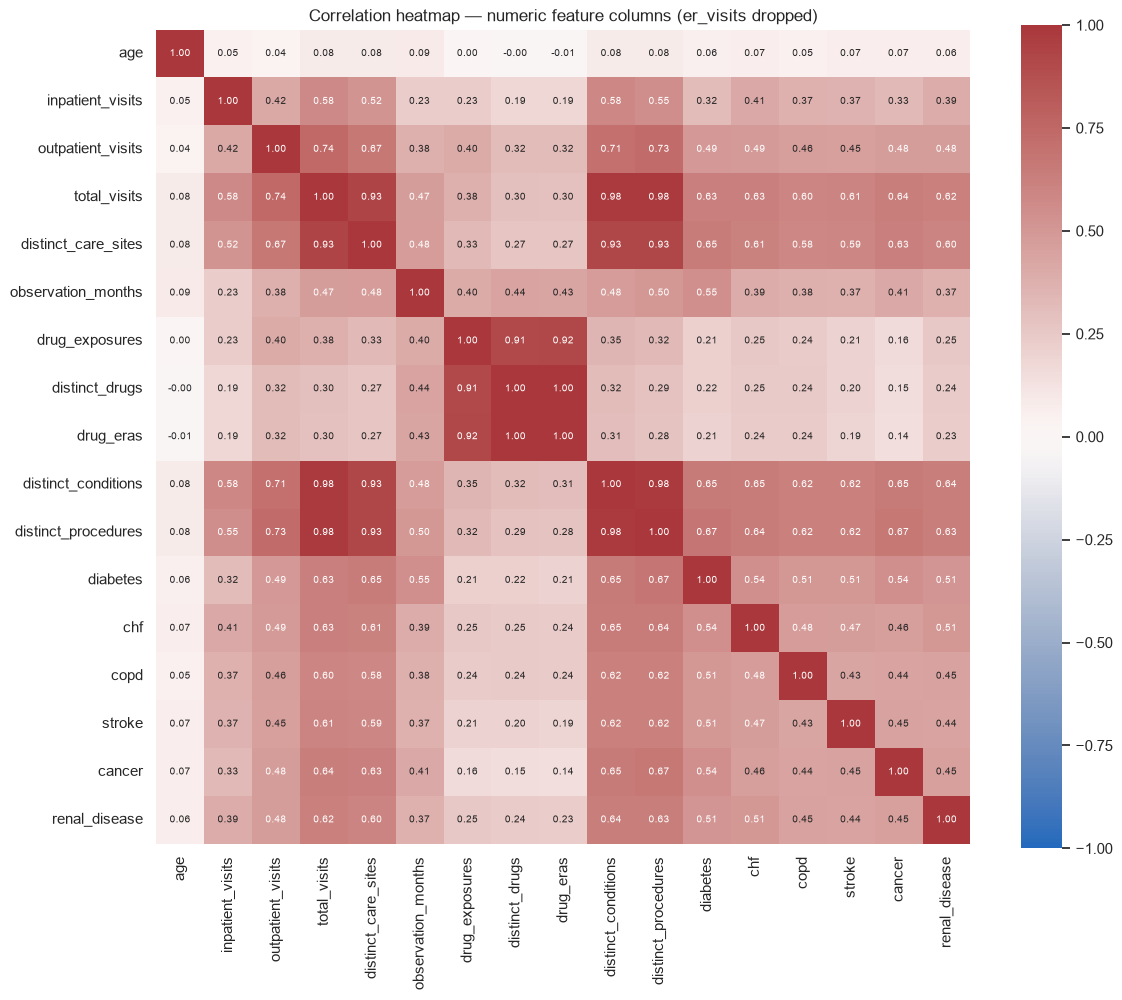

In [8]:
NUMERIC = ["age", *COUNT_COLS, *CHRONIC]
NUMERIC.remove("er_visits")  # zero-variance: undefined/NaN correlations
corr = df[NUMERIC].corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0,
            vmin=-1, vmax=1, square=True, ax=ax, annot_kws={"size": 7})
ax.set_title("Correlation heatmap — numeric feature columns (er_visits dropped)")
plt.tight_layout()
plt.show()


In [9]:
s = corr.abs().unstack()
s = s[s < 0.999].dropna().sort_values(ascending=False)
pairs = [(a, b, round(v, 3)) for (a, b), v in s.items() if a < b][:12]
print("Top |corr| feature pairs (excluding self-pairs):")
for a, b, v in pairs:
    print(f"  {a:<22} x {b:<22} {v:.3f}")

# Utilization-breadth vs demographics (er_visits excluded: zero-variance)
count_cols_no_er = [c for c in COUNT_COLS if c != "er_visits"]
print("\nCorrelation of count features with age / observation_months:")
print(corr.loc[["age", "observation_months"], count_cols_no_er].round(3).to_string())


Top |corr| feature pairs (excluding self-pairs):
  distinct_drugs         x drug_eras              0.997
  distinct_conditions    x total_visits           0.984
  distinct_conditions    x distinct_procedures    0.979
  distinct_procedures    x total_visits           0.978
  distinct_care_sites    x total_visits           0.932
  distinct_care_sites    x distinct_conditions    0.926
  distinct_care_sites    x distinct_procedures    0.925
  drug_eras              x drug_exposures         0.919
  distinct_drugs         x drug_exposures         0.907
  outpatient_visits      x total_visits           0.743
  distinct_procedures    x outpatient_visits      0.731
  distinct_conditions    x outpatient_visits      0.710

Correlation of count features with age / observation_months:
                    inpatient_visits  outpatient_visits  total_visits  distinct_care_sites  observation_months  drug_exposures  distinct_drugs  drug_eras  distinct_conditions  distinct_procedures
age                  

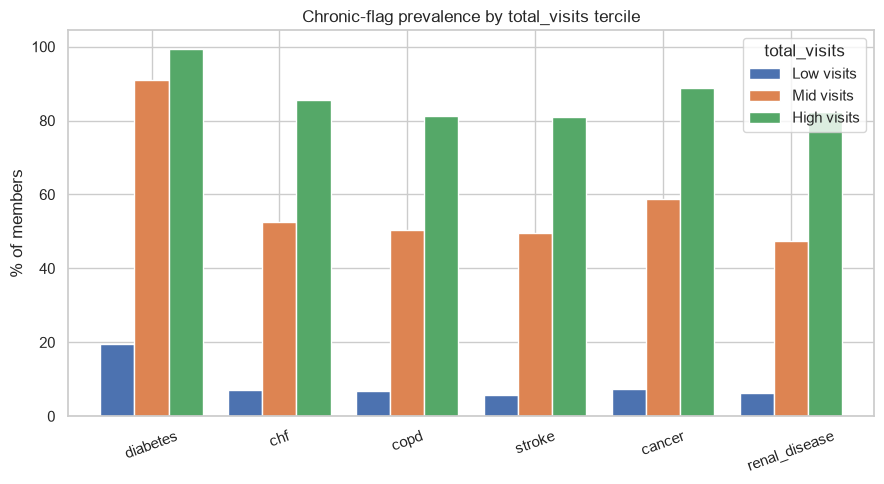

total_visits,Low visits,Mid visits,High visits
diabetes,19.6,90.9,99.4
chf,7.2,52.7,85.6
copd,6.7,50.5,81.1
stroke,5.7,49.7,81.1
cancer,7.4,58.9,88.8
renal_disease,6.4,47.4,82.4


In [10]:
# Chronic-flag prevalence x utilization terciles (terciles of total_visits)
util_tercile = pd.qcut(df["total_visits"], 3, labels=["Low visits", "Mid visits", "High visits"])
ct = df.groupby(util_tercile, observed=True)[CHRONIC].mean().T * 100

fig, ax = plt.subplots(figsize=(9, 5))
ct.plot.bar(ax=ax, width=0.8)
ax.set_title("Chronic-flag prevalence by total_visits tercile")
ax.set_ylabel("% of members")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()
ct.round(1)


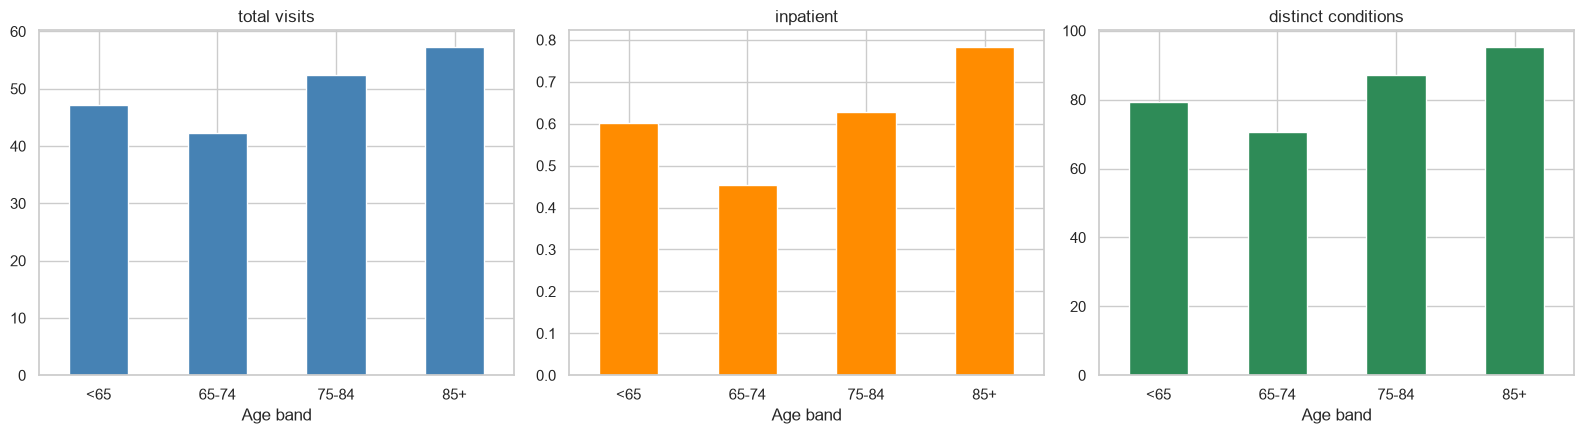

,members,mean_total_visits,mean_inpatient,mean_distinct_conditions
age_band,,,,
<65,16313,47.12,0.60,79.41
65-74,42542,42.25,0.45,70.72
75-84,28123,52.38,0.63,87.29
85+,13022,57.31,0.78,95.30


In [11]:
# Age band x utilization
age_util = df.groupby("age_band", observed=True).agg(
    members=("person_id", "size"),
    mean_total_visits=("total_visits", "mean"),
    mean_inpatient=("inpatient_visits", "mean"),
    mean_distinct_conditions=("distinct_conditions", "mean"),
).reindex(["<65", "65-74", "75-84", "85+"])

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, col, color in [
    (axes[0], "mean_total_visits", "steelblue"),
    (axes[1], "mean_inpatient", "darkorange"),
    (axes[2], "mean_distinct_conditions", "seagreen"),
]:
    age_util[col].plot.bar(ax=ax, color=color)
    ax.set_title(col.replace("mean_", "").replace("_", " "))
    ax.set_xlabel("Age band")
    ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()
age_util.round(2)


**Takeaways.**
- **A tight utilization-breadth cluster dominates the correlations:** `distinct_conditions`–`total_visits` (r = 0.98), `distinct_conditions`–`distinct_procedures` (0.98), `total_visits`–`distinct_procedures` (0.98), and `distinct_care_sites`–`total_visits` (0.93). The pharmacy trio (`drug_exposures`, `distinct_drugs`, `drug_eras`) is nearly collinear internally (0.91–0.997). Counts within each cluster carry almost the same information; the modeling phase should regularize or thin these rather than feed all of them raw.
- **Age is nearly orthogonal to the utilization counts** (|r| ≤ 0.09) and only weakly positively correlated with chronic flags (r ≈ 0.05–0.07) — age alone will not proxy risk, but it is a near-independence demographic, good for stratification.
- **Chronic flags scale monotonically with utilization:** every flag climbs steeply across `total_visits` terciles — from single-digit prevalence in the lowest tercile to ~80–99% in the highest (e.g. CHF 7% → 53% → 86%; diabetes 20% → 91% → 99%). The flags are themselves correlated with the counts (r ≈ 0.6, up to 0.67), so they are not independent evidence — the proxy preview in §4 tests whether they add separation on top of the counts.
- **Utilization is non-monotonic in age:** mean total visits *dip* from <65 (47.1) to 65–74 (42.3) — the non-monotonic young end is consistent with the disabled-eligible <65 population — then rise steadily through 75–84 (52.4) to a peak at 85+ (57.3). Keep all four age bands as one-hot features rather than assuming a monotonic age effect.
- **Count features are exposure-time-dependent.** `observation_months` correlates r = 0.47 with `total_visits`; 10,679 members (10.7%) have zero observation months, and 99.6% of those have zero visits. Part of the zero-inflated tail is therefore a *not-observed* artifact, not observed low utilization — the modeling phase should use rate features (counts per observation month) or at minimum control for `observation_months`.


## 4. Class-proxy preview — can the features separate utilization tiers?

**This is a sanity check, not the RFC target.** The RFC outcome (Low/Medium/High utilization risk) is constructed in a later phase. Here we define a transparent **proxy score** from count features only —

`proxy = total_visits + 3 x inpatient_visits + drug_eras`

(inpatient rows weighted 3x because they are the costliest setting; drug eras add pharmacy intensity) — split into terciles, and ask whether the *other* features separate across proxy groups. Separability here means a future model has signal to learn; overlap means the tiers will need the chronic/demographic features, not counts alone.

In [12]:
proxy_score = df["total_visits"] + 3 * df["inpatient_visits"] + df["drug_eras"]
proxy = pd.qcut(proxy_score, 3, labels=["Low", "Medium", "High"])

print("Proxy group sizes (terciles of the score):")
print(proxy.value_counts().sort_index().to_string())

grouped = df.groupby(proxy, observed=True)
summary = grouped[
    ["age", "inpatient_visits", "outpatient_visits", "total_visits",
     "distinct_care_sites", "drug_exposures", "distinct_drugs",
     "distinct_conditions", "distinct_procedures", "observation_months"]
].mean().T.round(2)
summary.columns = [f"{c} (n={proxy.value_counts()[c]:,})" for c in summary.columns]
summary


Proxy group sizes (terciles of the score):
Low       33474
Medium    33266
High      33260


,"Low (n=33,474)","Medium (n=33,266)","High (n=33,260)"
age,70.45,72.60,72.07
inpatient_visits,0.12,0.43,1.16
outpatient_visits,1.79,5.98,12.28
total_visits,12.92,44.53,86.34
distinct_care_sites,9.90,29.84,51.72
drug_exposures,9.14,39.85,114.01
distinct_drugs,8.64,36.82,97.79
distinct_conditions,22.44,75.68,142.25
distinct_procedures,20.39,61.96,108.45
observation_months,17.37,31.35,32.61


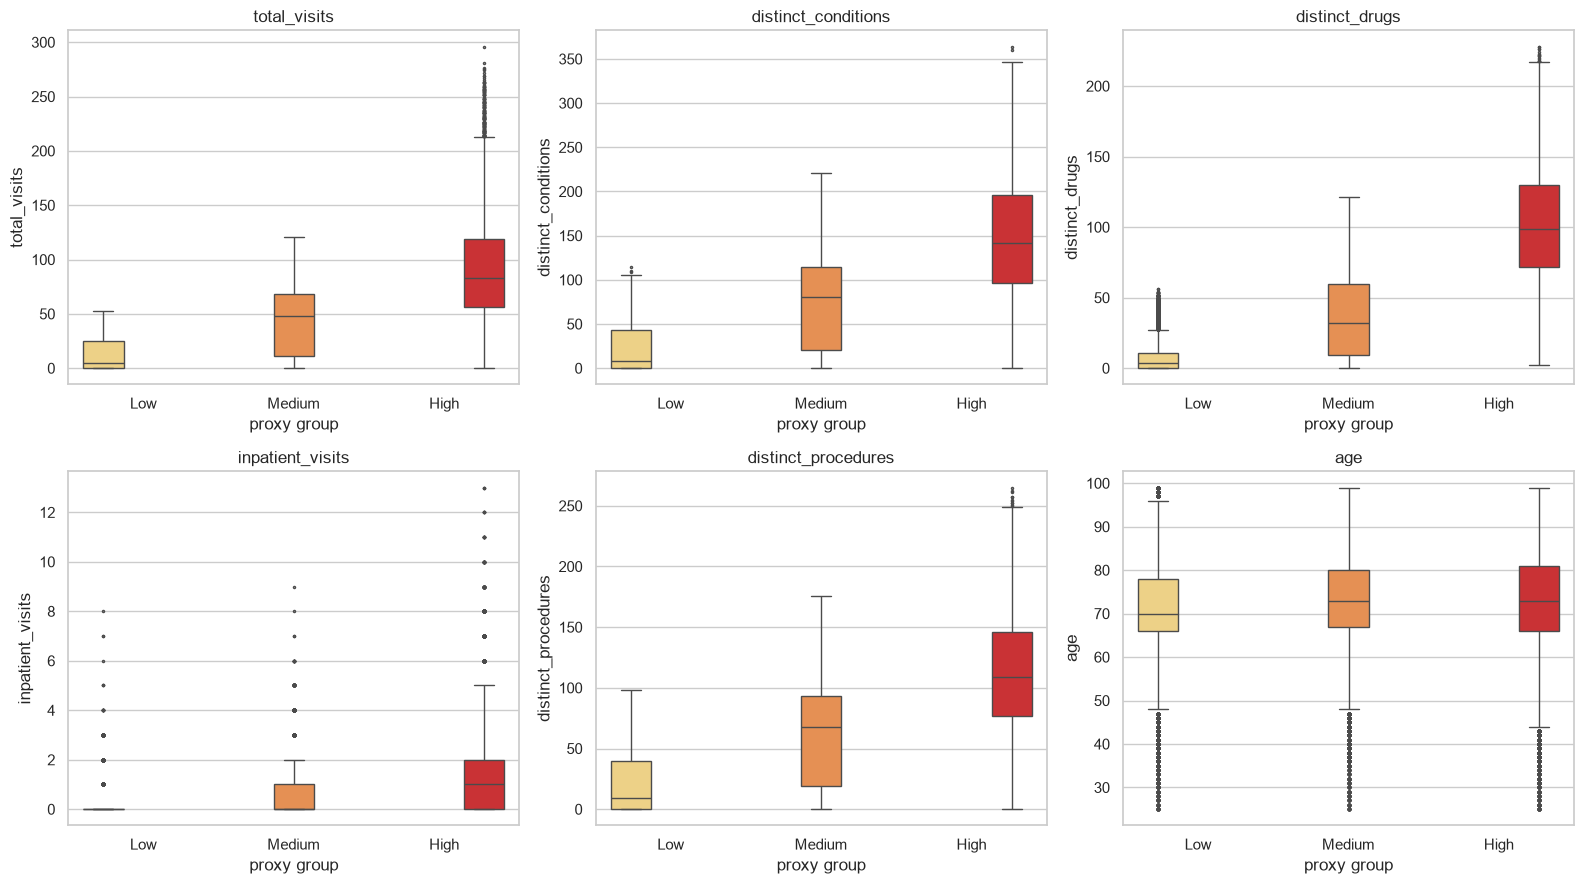

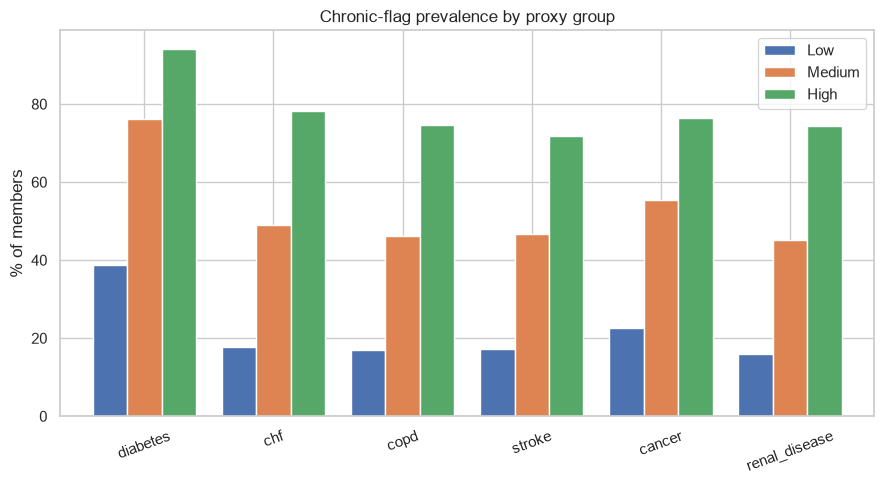

,Low,Medium,High
diabetes,38.7,76.1,94.2
chf,17.7,49.1,78.1
copd,16.9,46.2,74.7
stroke,17.3,46.7,71.9
cancer,22.6,55.4,76.5
renal_disease,16.0,45.1,74.5


In [13]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.ravel(),
                   ["total_visits", "distinct_conditions", "distinct_drugs",
                    "inpatient_visits", "distinct_procedures", "age"]):
    sns.boxplot(x=proxy, y=df[col], order=["Low", "Medium", "High"], ax=ax,
                hue=proxy, palette="YlOrRd", legend=False, fliersize=1.5)
    ax.set_title(col)
    ax.set_xlabel("proxy group")
plt.tight_layout()
plt.show()

# Chronic-flag prevalence by proxy group (cross-tab on the proxy)
flag_by_proxy = grouped[CHRONIC].mean().T * 100
fig, ax = plt.subplots(figsize=(9, 5))
flag_by_proxy.plot.bar(ax=ax, width=0.8)
ax.set_title("Chronic-flag prevalence by proxy group")
ax.set_ylabel("% of members")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()
flag_by_proxy.round(1)


**Takeaways.** The proxy groups separate cleanly and monotonically: mean total visits 12.9 → 44.5 → 86.3, inpatient visits 0.1 → 0.4 → 1.2, and all six chronic flags climb steeply across groups (e.g. diabetes 39% → 76% → 94%; CHF 18% → 49% → 78%). Note that `total_visits`, `inpatient_visits` and `drug_eras` are *components* of the proxy score, so their separation is by construction — the honest separability evidence is the non-component breadth features, which separate just as cleanly and monotonically (`distinct_conditions` 22 → 76 → 142; `distinct_drugs` 9 → 37 → 98). The chronic flags are correlated with the raw counts (r ≈ 0.6–0.67), so they are not independent evidence, but their steep rise across groups on top of that correlation indicates real signal beyond counts alone. The boxes overlap substantially (distributions are skewed, not bimodal), so a future classifier will rely on the joint pattern of counts + flags, exactly as the EDA anticipated. **Caveat restated:** this proxy is a *profile sanity check only*; the actual Low/Medium/High target must be defined in the modeling phase per the RFC, and any final choice should be validated against these features with the same style of separability check.


## 5. Summary — what the modeling phase inherits

- **The artifact is clean and complete:** 100k rows == 100k distinct members, zero nulls, all counts/flags int64, nominal columns clearly typed (`race`/`ethnicity` as integer codes — one-hot, never ordinal). Nothing to impute or repair.
- **Follow the Modeling contract in `src/build_features.py`:** drop `person_id` (row key) and `er_visits` (zero-variance); one-hot `gender`, `age_band`, `race`, `ethnicity`, `state` (`age_band` ordered but not ordinal-distance); use count/flag columns as-is. Consider dropping `ethnicity` — it is byte-identical to `race` in this export.
- **Expect heavy multicollinearity** inside the utilization-breadth cluster (`total_visits`/`distinct_conditions`/`distinct_procedures`/`distinct_care_sites`, r ≥ 0.93) and the pharmacy cluster (r ≥ 0.91); regularization or cluster thinning is advised rather than naive unregularized models.
- **Treat the zero-inflated minority carefully.** ~15% of members have zero visits, but 10.7% have zero observation months and 99.6% of those have zero visits — much of the visible "Low" tail is a not-observed artifact rather than observed low utilization. Prefer count-per-observation-month rate features, or include `observation_months` as a control, before interpreting low counts as low risk.
- **Caveats that constrain interpretation:** no spending columns exist (utilization intensity proxies spending); chronic flags are ICD-9 ANY-match flags inflated by claim-line duplication (utilization-flavored, not clinical truth); ~85% of visits are untyped so typed visit counts undercount activity; `state` includes the unresolvable "54" code; all findings are on fully synthetic data with limited inferential value.
